In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('house_prices_practice.csv')
print(df.isnull().sum())

Id              0
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
LotArea         0
SalePrice       0
dtype: int64


In [3]:
df=df.drop('Id', axis=1)

In [4]:
df

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,7,1560,0,1658,1969,2,1,8059,177106
1,4,2827,2,1319,2012,3,4,13530,301044
2,8,3920,0,841,2010,1,4,9010,360609
3,5,3044,0,1058,1998,0,4,13207,240556
4,7,801,1,2428,2020,0,1,9117,193656
...,...,...,...,...,...,...,...,...,...
295,1,3495,1,1792,1954,2,5,4978,250604
296,5,3438,3,1266,2003,0,1,9373,329906
297,6,1992,0,1148,1996,1,1,7907,184623
298,3,3722,1,1407,1998,1,1,8097,303345


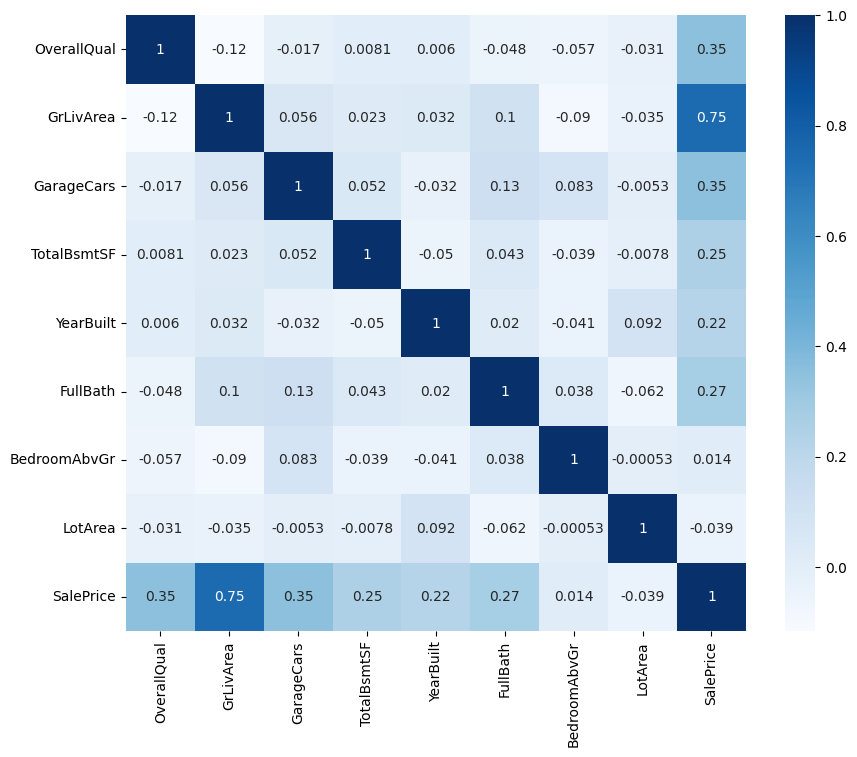

In [5]:
corr_matrix=df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,cmap='Blues')
plt.show()

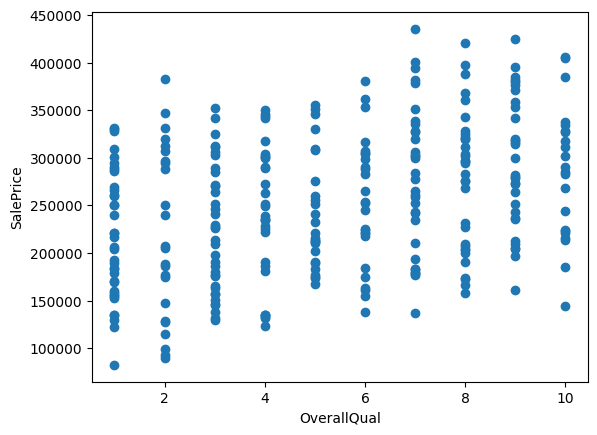

In [6]:
x=df.iloc[:,0]
y=df.iloc[:,8]
plt.scatter(x,y)
plt.xlabel('OverallQual')
plt.ylabel('SalePrice')
plt.show()

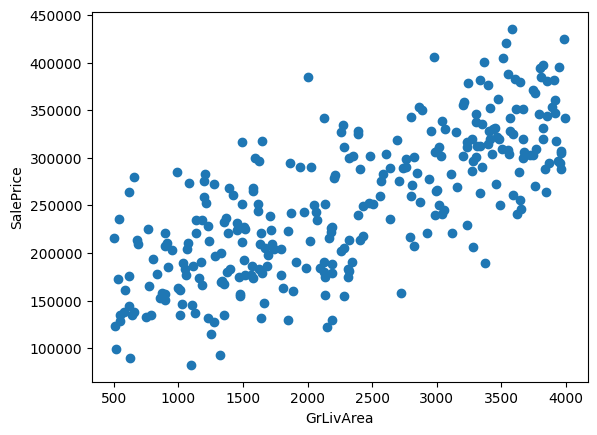

In [7]:
x=df.iloc[:,1]
y=df.iloc[:,8]
plt.scatter(x,y)
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.show()

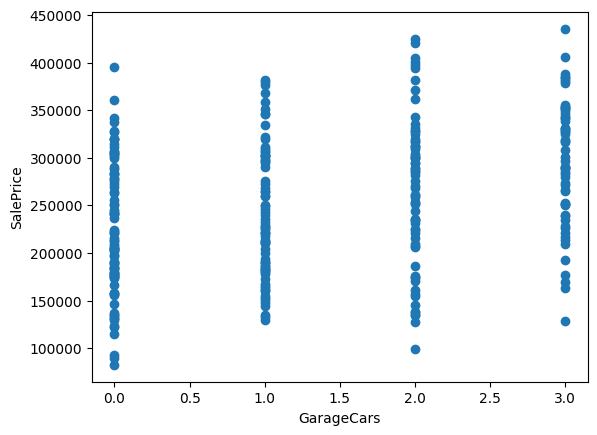

In [8]:
x=df.iloc[:,2]
y=df.iloc[:,8]
plt.scatter(x,y)
plt.xlabel('GarageCars')
plt.ylabel('SalePrice')
plt.show()

In [9]:
n=df[['OverallQual','GrLivArea','GarageCars']].values
m=df['SalePrice'].values
m=m.reshape(-1,1)

In [10]:
mean=np.mean(n,axis=0)
std=np.std(n,axis=0)
n_scalled=(n-mean)/std

In [11]:
w=np.random.rand(4,1)

In [12]:
n_new=np.hstack((np.ones((len(n_scalled),1)),n_scalled))
h=n_new @ w
E=h-m
w=w-((0.001/len(n_scalled))*n_new.T@E)

In [13]:
cost_history=[]
for i in range(1000):
  h=n_new @ w
  E=h-m
  cost=(1/(2*len(n_scalled)))*np.sum(np.square(E))
  cost_history.append(cost)
  w= w-((0.001/len(n_scalled))*n_new.T@E)
print('complete trainig!')

complete trainig!


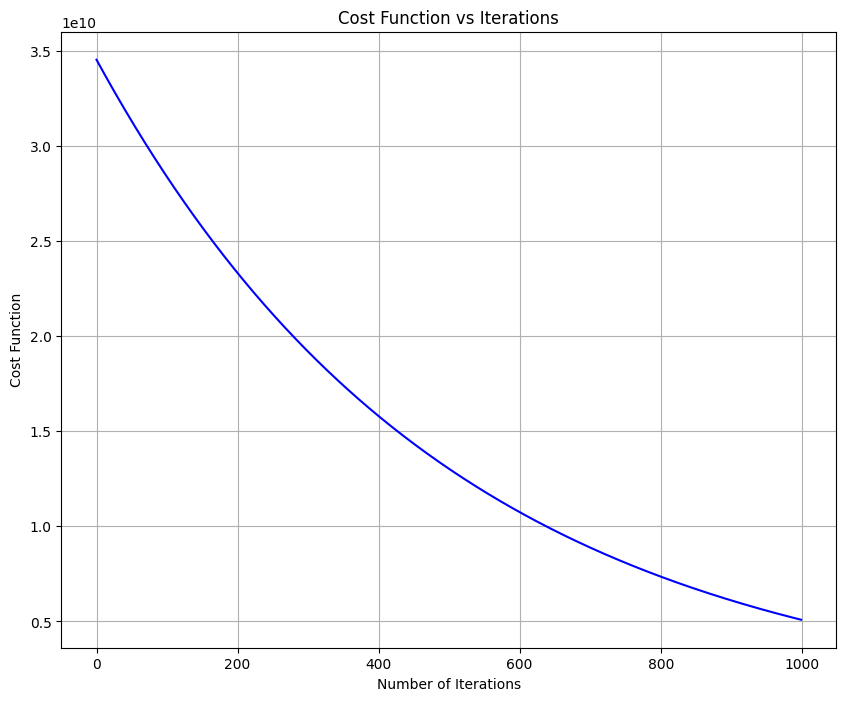

In [14]:
plt.figure(figsize=(10,8))
plt.plot(range(1000),cost_history,color='blue')
plt.title('Cost Function vs Iterations')
plt.xlabel('Number of Iterations')
plt.ylabel('Cost Function')
plt.grid(True)
plt.show()